# Energía solar en España - predecir lo de mañana

Lo que quiero responder es: ¿cuánta solar va a hacer mañana en España? Lo mido en GWh por día y es lo que usa Red Eléctrica para organizarse.

Es un problema de predecir una serie en el tiempo. La columna a adivinar es `solar_gwh`.

Tiro de dos sitios: REE para la solar de cada día y Open-Meteo para la radiación y la temperatura en Madrid, que uso como referencia. Todo está en `data/solar_espana.csv` (1366 días, del 2023-01-01 al 2026-09-27).

Para predecir solo puedo usar lo que sabría la víspera: el calendario, la meteo prevista y lo de los días anteriores. En este cuaderno dejo la limpieza y las gráficas hechas aquí mismo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

df = pd.read_csv('data/solar_espana.csv', parse_dates=['fecha'])
print(df.shape)
df.head()

(1366, 4)


,fecha,solar_gwh,radiacion_MJm2,temp_media_Madrid
0,2023-01-01,34.900980,7.52,8.5
1,2023-01-02,31.904641,5.49,9.0
2,2023-01-03,53.978712,8.85,7.0
3,2023-01-04,58.475944,9.35,5.0
4,2023-01-05,58.507717,9.35,4.7


## 2 - Repaso de los datos antes de tocar nada

Antes de cambiar nada miro:
1. Si hay huecos, fechas repetidas o días que faltan.
2. Si hay valores que no tienen sentido (`solar_gwh <= 0` o radiación negativa).
3. Si los días más raros son fallos o son reales (un día muy nublado o un verano con más placas).


In [2]:
print(f'Filas antes: {len(df)}')
print('Nulos totales:', int(df.isna().sum().sum()))
print('Duplicados fecha:', int(df.duplicated('fecha').sum()))
esperadas = len(pd.date_range(df.fecha.min(), df.fecha.max()))
print('Fechas faltantes:', esperadas - len(df))
print('solar<=0:', int((df.solar_gwh <= 0).sum()), '| radiacion<0:', int((df.radiacion_MJm2 < 0).sum()))
print()
print('Extremos solar:')
print(df.nlargest(3, 'solar_gwh')[['fecha', 'solar_gwh', 'radiacion_MJm2']].to_string(index=False))
print(df.nsmallest(3, 'solar_gwh')[['fecha', 'solar_gwh', 'radiacion_MJm2']].to_string(index=False))

Filas antes: 1366
Nulos totales: 0
Duplicados fecha: 0
Fechas faltantes: 0
solar<=0: 0 | radiacion<0: 0

Extremos solar:
     fecha  solar_gwh  radiacion_MJm2
2026-08-05  287.15849           27.23
2026-08-11  280.45549           27.41
2026-07-08  280.23309           29.94
     fecha  solar_gwh  radiacion_MJm2
2023-01-08  17.719340            3.31
2024-01-19  22.096582            2.26
2024-01-15  22.949573            3.23


Salió todo a cero: 0 nulos, 0 repetidos, 0 días perdidos y 0 imposibles. Los mínimos (unos 17 GWh un día nublado de invierno) y los máximos (unos 287 GWh en verano de 2026) cuadran con la meteo y con que cada año hay más potencia. Así que no quito ninguna fila.

Solo ordeno por fecha, saco unas columnas de la fecha que siempre se saben de antemano y guardo `data/solar_espana_clean.csv`.


In [3]:
df = df.sort_values('fecha').reset_index(drop=True)
df['dow'] = df.fecha.dt.dayofweek        # 0=Lun ... 6=Dom
df['month'] = df.fecha.dt.month
df['dayofmonth'] = df.fecha.dt.day
df['dayofyear'] = df.fecha.dt.dayofyear
df['year'] = df.fecha.dt.year
df['weekend'] = (df.dow >= 5).astype(int)
df.to_csv('data/solar_espana_clean.csv', index=False)
print(f'Filas después: {len(df)} -> data/solar_espana_clean.csv')
df.describe().round(2)

Filas después: 1366 -> data/solar_espana_clean.csv


,fecha,solar_gwh,radiacion_MJm2,temp_media_Madrid,dow,month,dayofmonth,dayofyear,year,weekend
count,1366,1366.00,1366.00,1366.00,1366.0,1366.00,1366.00,1366.00,1366.00,1366.00
mean,2024-11-13 12:00:00,132.51,17.76,16.56,3.0,6.22,15.69,173.75,2024.40,0.29
min,2023-01-01 00:00:00,17.72,1.77,0.30,0.0,1.00,1.00,1.00,2023.00,0.00
25%,2023-12-08 06:00:00,85.18,9.84,9.30,1.0,3.00,8.00,86.00,2023.00,0.00
50%,2024-11-13 12:00:00,128.56,18.56,15.60,3.0,6.00,16.00,171.00,2024.00,0.00
75%,2025-10-20 18:00:00,172.47,25.35,24.00,5.0,9.00,23.00,256.75,2025.00,1.00
max,2026-09-27 00:00:00,287.16,31.13,33.00,6.0,12.00,31.00,366.00,2026.00,1.00
std,NaN,57.88,8.39,8.59,2.0,3.35,8.79,102.43,1.08,0.45


## 3 - Mirar los datos con calma

Primero los números gordos: qué se parece a la solar y cuánto sale de media por año y por mes. Luego ya los gráficos.


In [4]:
print('Correlaciones con solar_gwh:')
print(df[['solar_gwh', 'radiacion_MJm2', 'temp_media_Madrid', 'dow', 'month', 'dayofyear']].corr()['solar_gwh'].sort_values(ascending=False).to_string())
print('\nMedia anual (tendencia por capacidad instalada):')
print(df.groupby('year')['solar_gwh'].agg(['count', 'mean', 'max']).round(1).to_string())
print('\nMedia mensual:')
print(df.groupby('month')['solar_gwh'].mean().round(1).to_string())

Correlaciones con solar_gwh:
solar_gwh            1.000000
radiacion_MJm2       0.848102
temp_media_Madrid    0.764411
month                0.090235
dayofyear            0.088778
dow                 -0.068792

Media anual (tendencia por capacidad instalada):
      count   mean    max
year                     
2023    365  102.6  163.0
2024    366  121.9  212.2
2025    365  137.7  240.6
2026    270  180.3  287.2

Media mensual:
month
1      66.9
2      93.4
3     109.4
4     141.3
5     162.5
6     181.9
7     196.9
8     185.9
9     159.0
10    102.0
11     83.0
12     71.3


### Serie de cada día

Aquí se ve que en verano sale mucha más solar y en invierno poca, y que la media va subiendo con los años porque se ponen más placas. La media de 30 días lo deja muy claro.


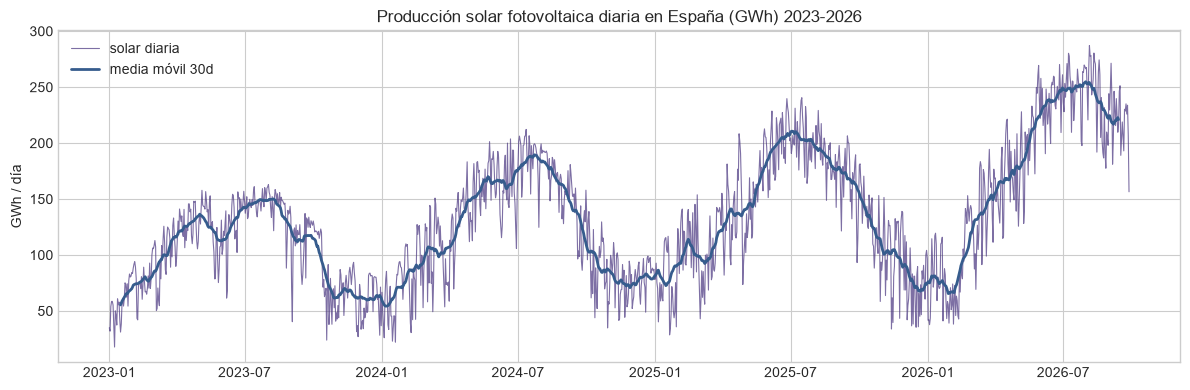

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.fecha, df.solar_gwh, lw=0.8, alpha=0.7, label='solar diaria')
ax.plot(df.fecha, df.solar_gwh.rolling(30, center=True).mean(), lw=2, label='media móvil 30d')
ax.set_title('Producción solar fotovoltaica diaria en España (GWh) 2023-2026')
ax.set_ylabel('GWh / día')
ax.legend()
fig.tight_layout()
plt.show()

Se nota el ciclo de cada año y que la media sube (102.6 en 2023, 121.9 en 2024, 137.7 en 2025 y 180.3 en 2026). Para el modelo me quedo con que hacen falta cosas de estación (`dayofyear`, `month`, radiación) y algo para la subida (`year` o los lags).

### Radiación contra solar, que es lo que más manda


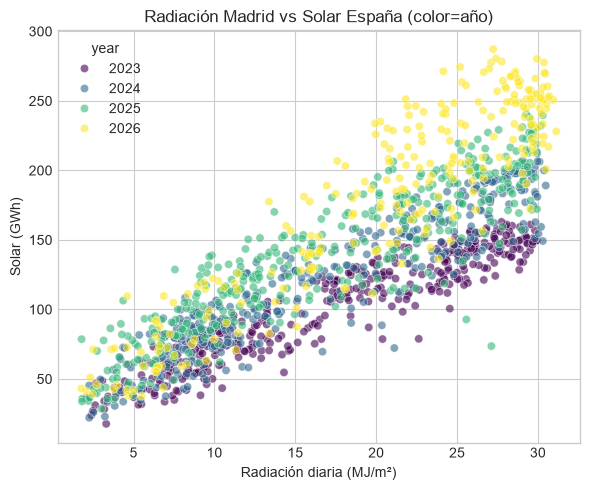

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=df, x='radiacion_MJm2', y='solar_gwh', hue='year', palette='viridis', alpha=0.6, ax=ax)
ax.set_title('Radiación Madrid vs Solar España (color=año)')
ax.set_xlabel('Radiación diaria (MJ/m²)')
ax.set_ylabel('Solar (GWh)')
fig.tight_layout()
plt.show()

Cuanto más sol, más solar, con una correlación de 0.85. Y se ve que con la misma radiación los últimos años dan más GWh porque hay más capacidad. Ya adelanto que probar con y sin radiación va a cambiar bastante.

### Cómo cambia por mes


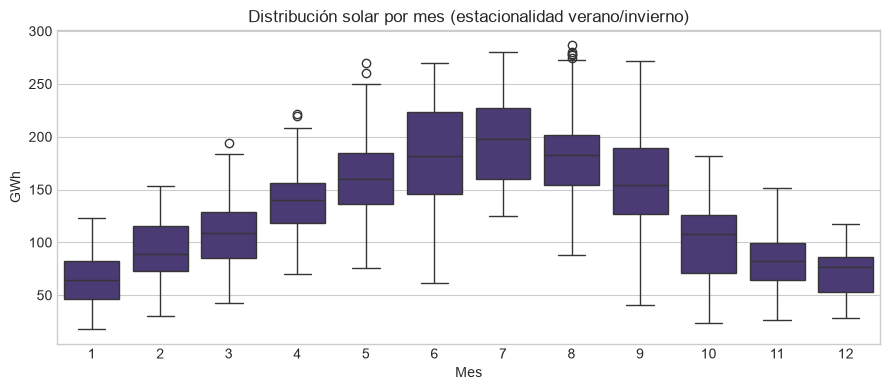

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df, x='month', y='solar_gwh', ax=ax)
ax.set_title('Distribución solar por mes (estacionalidad verano/invierno)')
ax.set_xlabel('Mes')
ax.set_ylabel('GWh')
fig.tight_layout()
plt.show()

Julio da unos 196.9 GWh y enero unos 66.9, el triple. En verano sale mucho y estable, en invierno poco y con más altibajos por nubes. El mes y el día del año los voy a necesitar sí o sí.

### Temperatura y media por año


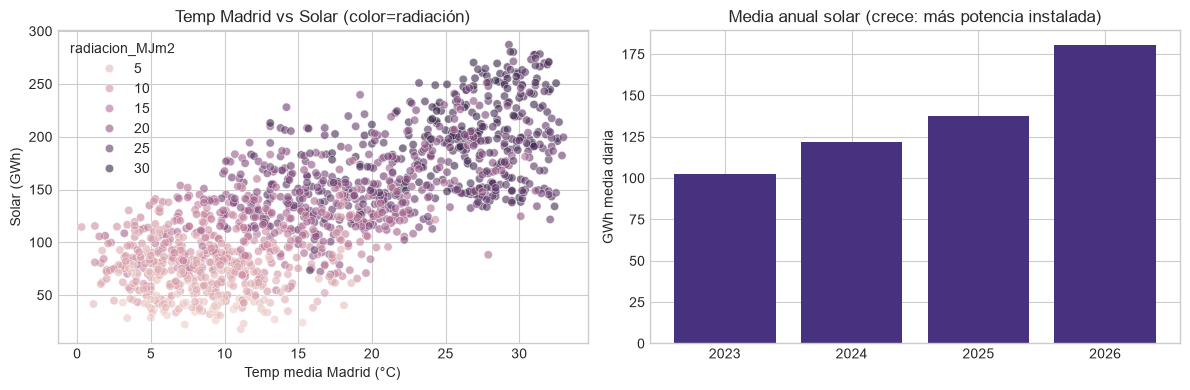

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x='temp_media_Madrid', y='solar_gwh', hue='radiacion_MJm2', alpha=0.6, ax=axes[0])
axes[0].set_title('Temp Madrid vs Solar (color=radiación)')
axes[0].set_xlabel('Temp media Madrid (°C)')
axes[0].set_ylabel('Solar (GWh)')
ann = df.groupby('year')['solar_gwh'].mean()
axes[1].bar(ann.index.astype(str), ann.values)
axes[1].set_title('Media anual solar (crece: más potencia instalada)')
axes[1].set_ylabel('GWh media diaria')
fig.tight_layout()
plt.show()

La temperatura también acompaña (0.76) pero menos que la radiación (0.85): a igual temperatura lo que manda es si hubo sol. Y la media por año sube cada año, no porque haga más sol sino porque hay más placas.

### ¿Influye el día de la semana?


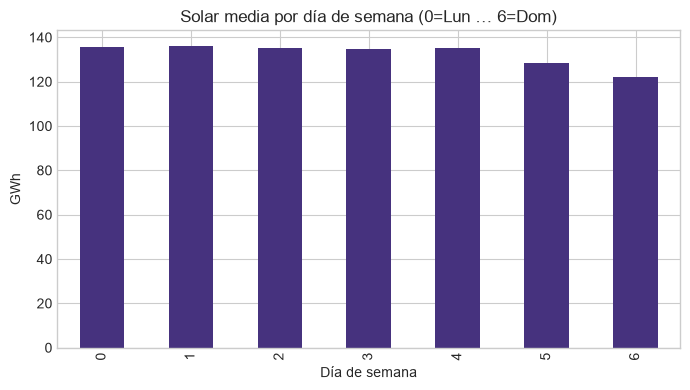

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
df.groupby('dow')['solar_gwh'].mean().plot(kind='bar', ax=ax)
ax.set_title('Solar media por día de semana (0=Lun … 6=Dom)')
ax.set_ylabel('GWh')
ax.set_xlabel('Día de semana')
fig.tight_layout()
plt.show()

### Cómo se reparten los valores

Miro los histogramas para ver si están sesgados o tienen dos picos. La solar debería tener pinta de dos montones: invierno abajo y verano arriba.


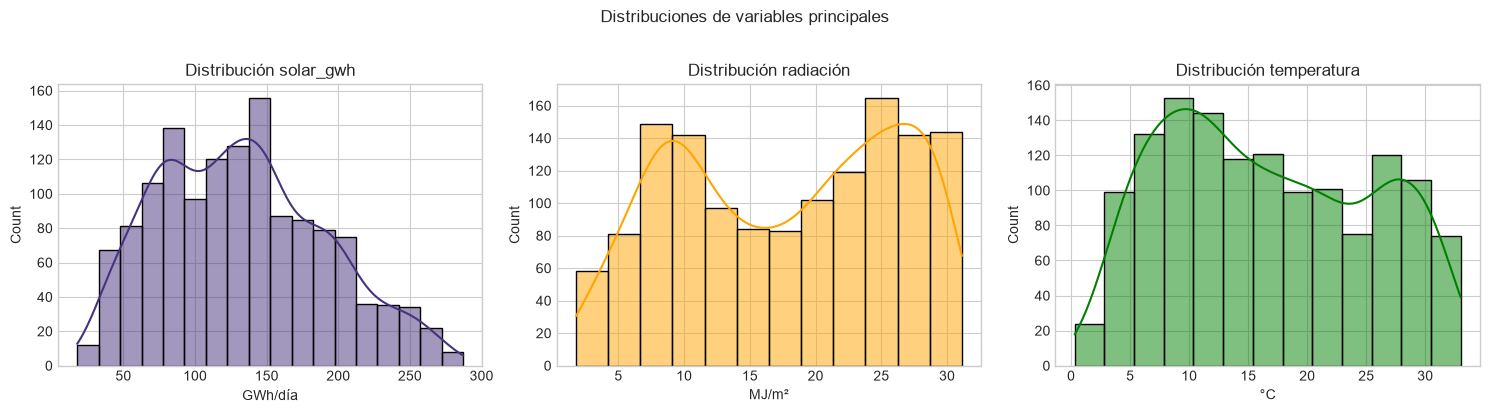

solar_gwh            0.36
radiacion_MJm2      -0.13
temp_media_Madrid    0.19


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['solar_gwh'], kde=True, ax=axes[0])
axes[0].set_title('Distribución solar_gwh')
axes[0].set_xlabel('GWh/día')
sns.histplot(df['radiacion_MJm2'], kde=True, ax=axes[1], color='orange')
axes[1].set_title('Distribución radiación')
axes[1].set_xlabel('MJ/m²')
sns.histplot(df['temp_media_Madrid'], kde=True, ax=axes[2], color='green')
axes[2].set_title('Distribución temperatura')
axes[2].set_xlabel('°C')
fig.suptitle('Distribuciones de variables principales', y=1.02)
fig.tight_layout()
plt.show()
print(df[['solar_gwh', 'radiacion_MJm2', 'temp_media_Madrid']].skew().round(2).to_string())

### Qué se parece a qué (correlaciones)

Una tabla con todo contra todo. Espero ver radiación y temperatura arriba y lo de la semana abajo.


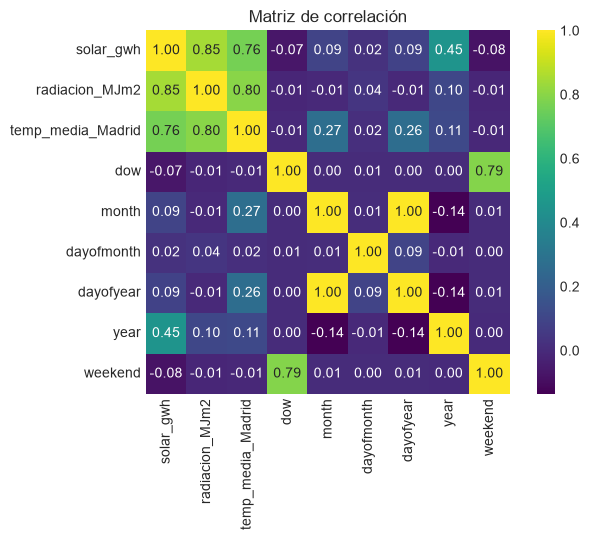

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cols = ['solar_gwh', 'radiacion_MJm2', 'temp_media_Madrid', 'dow', 'month', 'dayofmonth', 'dayofyear', 'year', 'weekend']
corr = df[cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='viridis', square=True, ax=ax)
ax.set_title('Matriz de correlación')
fig.tight_layout()
plt.show()

### Tabla año por mes

Con esto separo lo que es verano/invierno (columnas) de lo que es que cada año hay más placas (filas). Al lado pongo la media de cada mes con su variación.


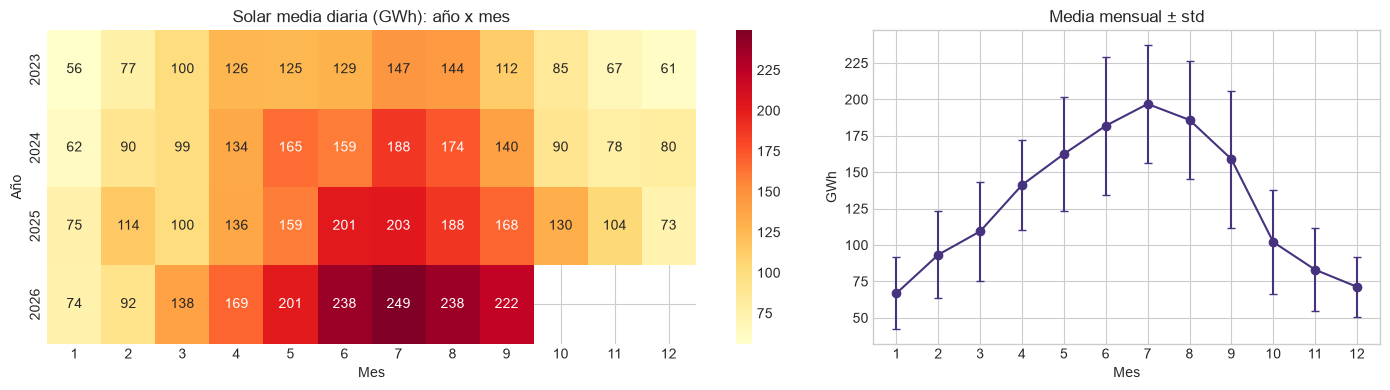

In [12]:
pivot = df.pivot_table(index='year', columns='month', values='solar_gwh', aggfunc='mean')
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={'width_ratios': [1.6, 1]})
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Solar media diaria (GWh): año x mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Año')
mensual = df.groupby('month')['solar_gwh'].agg(['mean', 'std'])
axes[1].errorbar(mensual.index, mensual['mean'], yerr=mensual['std'], marker='o', capsize=3)
axes[1].set_title('Media mensual ± std')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('GWh')
axes[1].set_xticks(range(1, 13))
fig.tight_layout()
plt.show()

### ¿Sube por más sol o por más placas? Y días raros

Divido `solar / radiación` por año: si sube es que hay más potencia aunque el sol sea parecido. Y remato con los 5 mejores y peores días.


Ratio solar/radiación por año (sube = más capacidad):
year
2023    6.46
2024    7.84
2025    9.43
2026    9.38


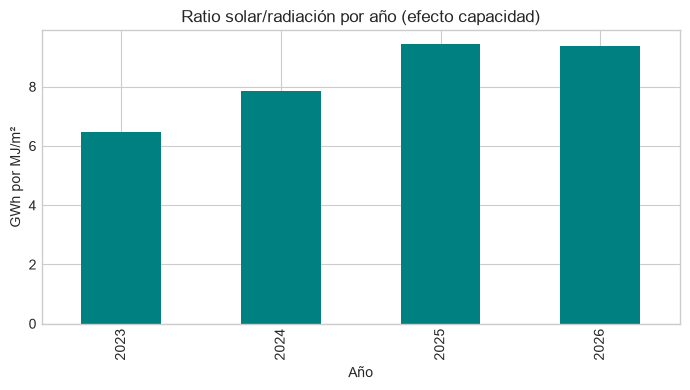


Top 5 días producción:
     fecha  solar_gwh  radiacion_MJm2  temp_media_Madrid  month  year
2026-08-05  287.15849           27.23               29.3      8  2026
2026-08-11  280.45549           27.41               29.4      8  2026
2026-07-08  280.23309           29.94               29.6      7  2026
2026-08-07  278.28930           27.76               31.4      8  2026
2026-07-09  277.63703           30.37               31.1      7  2026

Bottom 5 días producción:
     fecha  solar_gwh  radiacion_MJm2  temp_media_Madrid  month  year
2023-01-08  17.719340            3.31               11.1      1  2023
2024-01-19  22.096582            2.26                7.3      1  2024
2024-01-15  22.949573            3.23               11.3      1  2024
2023-10-19  23.919189            2.39               15.3     10  2023
2024-01-04  26.019065            2.52                9.4      1  2024


In [13]:
ratio = df.groupby('year').apply(lambda g: (g['solar_gwh'] / g['radiacion_MJm2']).mean(), include_groups=False)
print('Ratio solar/radiación por año (sube = más capacidad):')
print(ratio.round(2).to_string())
fig, ax = plt.subplots(figsize=(7, 4))
ratio.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Ratio solar/radiación por año (efecto capacidad)')
ax.set_ylabel('GWh por MJ/m²')
ax.set_xlabel('Año')
fig.tight_layout()
plt.show()
print('\nTop 5 días producción:')
print(df.nlargest(5, 'solar_gwh')[['fecha', 'solar_gwh', 'radiacion_MJm2', 'temp_media_Madrid', 'month', 'year']].to_string(index=False))
print('\nBottom 5 días producción:')
print(df.nsmallest(5, 'solar_gwh')[['fecha', 'solar_gwh', 'radiacion_MJm2', 'temp_media_Madrid', 'month', 'year']].to_string(index=False))

### Cuánto se parece hoy a los días anteriores

Si lo de ayer se parece mucho a hoy, me conviene meter lags. Si hubiera pico en 7 habría ritmo semanal (no lo espero en solar), y si baja lento es por el ciclo anual.


corr solar vs lag-1: 0.918
corr solar vs lag-2: 0.867
corr solar vs lag-3: 0.849
corr solar vs lag-7: 0.845


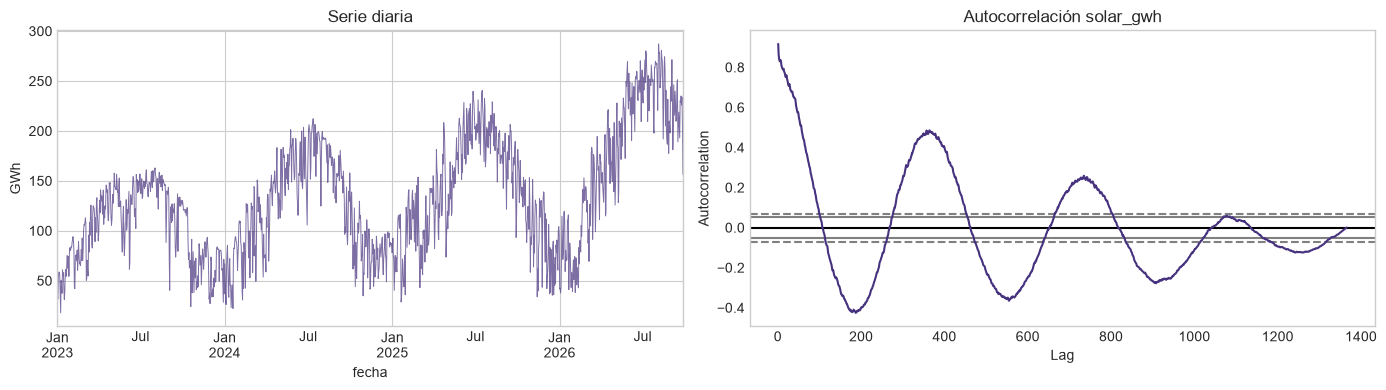

In [14]:
from pandas.plotting import autocorrelation_plot
for lag in [1, 2, 3, 7]:
    print(f'corr solar vs lag-{lag}: {df.solar_gwh.autocorr(lag):.3f}')
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.set_index('fecha')['solar_gwh'].plot(ax=axes[0], lw=0.7, alpha=0.7)
axes[0].set_title('Serie diaria')
axes[0].set_ylabel('GWh')
autocorrelation_plot(df['solar_gwh'], ax=axes[1])
axes[1].set_title('Autocorrelación solar_gwh')
fig.tight_layout()
plt.show()

El día de la semana casi no pinta nada (corr -0.07). Normal, el sol no mira el calendario como hacemos con la luz de casa. Dejo `dow` y `weekend` porque no molestan, pero sin esperar mucho.

## Qué me llevo para el modelo

1. La radiación es lo primero (0.85), hay que comparar con y sin ella.
2. Hay mucha estación, necesito `dayofyear` y `month` más radiación.
3. Cada año sale más por las placas nuevas, meto `year` o medias móviles.
4. La temperatura ayuda (0.76) pero es secundaria.
5. Lo de la semana da igual.

Ahora separo train/test y pruebo baselines y modelos.


## 4 - Cómo separo y qué baselines pongo

**Separo por fecha, sin mezclar:** train del 2023-01-31 al 2025-09-27 (971 días) y test los últimos 365 días (2025-09-28 al 2026-09-27). El test tiene un año entero y pilla 2026 que no se vio en train, que es lo que pasaría de verdad al usarlo.

**Lo que le doy al modelo (todo sabido la víspera):** calendario (`dow`, `month`, `dayofmonth`, `dayofyear`, `year`, `weekend` más `dayofyear_sin/cos` para el ciclo) + meteo del día + `lag1/2/3/7`, `roll7`, `roll30` con `shift(1)`. Por los lags se pierden las 30 primeras filas.

**Cómo mido:** MAE, RMSE, MAPE, R2 y acierto = 100*(1-MAPE), más % de días con error de menos del 10% / 20%, que es lo que más se entiende para negocio.


Filas tras lags: 1336 (descartadas 30)
train: 2023-01-31 -> 2025-09-27 (971 días)
test:  2025-09-28 -> 2026-09-27 (365 días)


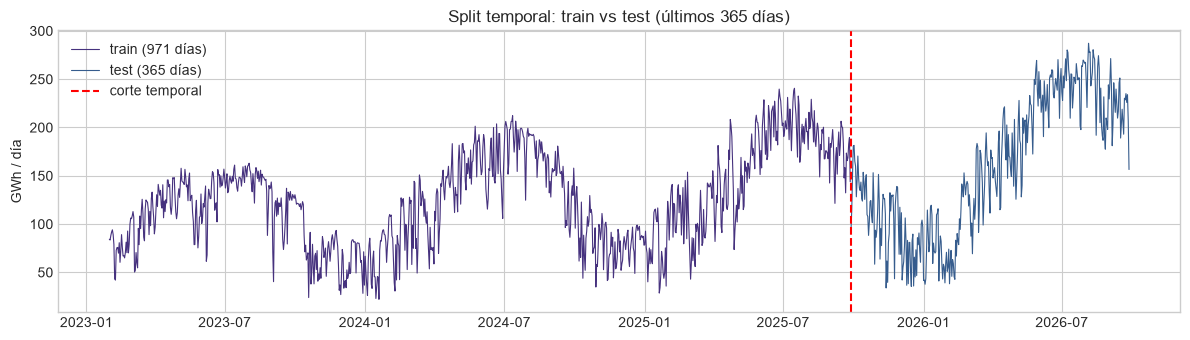

In [15]:
import numpy as np
dfm = df.copy()
dfm['dayofyear_sin'] = np.sin(2 * np.pi * dfm.dayofyear / 365.25)
dfm['dayofyear_cos'] = np.cos(2 * np.pi * dfm.dayofyear / 365.25)
for lag in [1, 2, 3, 7]:
    dfm[f'lag{lag}'] = dfm.solar_gwh.shift(lag)
dfm['roll7'] = dfm.solar_gwh.shift(1).rolling(7).mean()
dfm['roll30'] = dfm.solar_gwh.shift(1).rolling(30).mean()
dfm = dfm.dropna().reset_index(drop=True)
print(f'Filas tras lags: {len(dfm)} (descartadas {len(df) - len(dfm)})')
FEAT_FULL = ['radiacion_MJm2', 'temp_media_Madrid', 'dow', 'month', 'dayofmonth', 'dayofyear', 'year', 'weekend',
             'dayofyear_sin', 'dayofyear_cos', 'lag1', 'lag2', 'lag3', 'lag7', 'roll7', 'roll30']
FEAT_NOMET = [c for c in FEAT_FULL if c not in ('radiacion_MJm2', 'temp_media_Madrid')]
cutoff = dfm.fecha.max() - pd.Timedelta(days=364)
train = dfm[dfm.fecha < cutoff].reset_index(drop=True)
test = dfm[dfm.fecha >= cutoff].reset_index(drop=True)
print(f'train: {train.fecha.min().date()} -> {train.fecha.max().date()} ({len(train)} días)')
print(f'test:  {test.fecha.min().date()} -> {test.fecha.max().date()} ({len(test)} días)')
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(train.fecha, train.solar_gwh, lw=0.8, label=f'train ({len(train)} días)')
ax.plot(test.fecha, test.solar_gwh, lw=0.8, label=f'test ({len(test)} días)')
ax.axvline(cutoff, color='red', ls='--', label='corte temporal')
ax.set_title('Split temporal: train vs test (últimos 365 días)')
ax.set_ylabel('GWh / día')
ax.legend()
fig.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas(yt, yp):
    yt, yp = np.asarray(yt, float), np.asarray(yp, float)
    err = np.abs((yt - yp) / yt)
    return {'MAE': float(mean_absolute_error(yt, yp)),
            'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
            'MAPE': float(err.mean()),
            'R2': float(r2_score(yt, yp)),
            'Acierto': float(100 * (1 - err.mean())),
            'p10': float((err <= 0.10).mean() * 100),
            'p20': float((err <= 0.20).mean() * 100)}

yte = test.solar_gwh.values
base = {}
base['B0_naive_ayer'] = metricas(yte, test.lag1.values)          # mañana = hoy
base['B1_media_movil_7d'] = metricas(yte, test.roll7.values)     # media últimos 7 días
mm_hist = train.groupby('month').solar_gwh.mean()               # media histórica del mes
base['B2_media_mensual_hist'] = metricas(yte, test.month.map(mm_hist).values)
base_df = pd.DataFrame(base).T.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 3, 'Acierto': 1, 'p10': 1, 'p20': 1})
print(base_df.sort_values('MAE').to_string())
print('\nLectura: B0 y B1 empatan (~80% acierto). B2 se hunde (68.9%): usa medias 2023-2025 sin corregir por el crecimiento de potencia, así que infraestima 2026 sistemáticamente.' )

                         MAE   RMSE    MAPE     R2  Acierto   p10   p20
B1_media_movil_7d      22.03  27.43  0.1978  0.849     80.2  44.7  67.7
B0_naive_ayer          22.20  28.26  0.1985  0.839     80.2  44.9  69.0
B2_media_mensual_hist  48.70  57.44  0.3110  0.336     68.9   9.9  27.9

Lectura: B0 y B1 empatan (~80% acierto). B2 se hunde (68.9%): usa medias 2023-2025 sin corregir por el crecimiento de potencia, así que infraestima 2026 sistemáticamente.


## 5 - Pruebo 5 modelos iguales en test

Los pruebo todos con los mismos datos y el mismo test:

- **M1 lineal con meteo** (el de referencia, con todo).
- **M2 lineal sin meteo** (solo calendario + lags): para ver cuánto suma la meteo.
- **M3 RandomForest** (300 árboles).
- **M4 HistGradientBoosting**.
- **M5 RandomForest sin meteo** (para comparar sin meteo en no lineal).

Lo que creo que va a pasar: la meteo va a ayudar mucho (M1 contra M2) y los árboles lo van a tener peor con 2026 porque no lo vieron.


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

ytr = train.solar_gwh.values
res = dict(base)
preds = {}
for nombre, feats in [('M1_lineal_con_meteo', FEAT_FULL), ('M2_lineal_sin_meteo', FEAT_NOMET)]:
    m = LinearRegression().fit(train[feats], ytr)
    p = m.predict(test[feats])
    res[nombre] = metricas(yte, p)
    preds[nombre] = p
for nombre, feats, est in [
        ('M3_randomforest', FEAT_FULL, RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42)),
        ('M4_histgradientboosting', FEAT_FULL, HistGradientBoostingRegressor(max_iter=500, learning_rate=0.06, early_stopping=True, random_state=42)),
        ('M5_randomforest_sin_meteo', FEAT_NOMET, RandomForestRegressor(n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=42))]:
    est.fit(train[feats], ytr)
    p = est.predict(test[feats])
    res[nombre] = metricas(yte, p)
    preds[nombre] = p
    if 'randomforest' in nombre and 'sin' not in nombre:
        rf_model, rf_feats = est, feats
full_df = pd.DataFrame(res).T.round({'MAE': 2, 'RMSE': 2, 'MAPE': 4, 'R2': 3, 'Acierto': 1, 'p10': 1, 'p20': 1})
full_df = full_df.sort_values('MAE')
print(full_df.to_string())
print(f"\nMeteo en lineal: MAE {res['M2_lineal_sin_meteo']['MAE']:.2f} -> {res['M1_lineal_con_meteo']['MAE']:.2f} "
      f"| Acierto {res['M2_lineal_sin_meteo']['Acierto']:.1f}% -> {res['M1_lineal_con_meteo']['Acierto']:.1f}%")
print(f"Meteo en RF: MAE {res['M5_randomforest_sin_meteo']['MAE']:.2f} -> {res['M3_randomforest']['MAE']:.2f} "
      f"| Acierto {res['M5_randomforest_sin_meteo']['Acierto']:.1f}% -> {res['M3_randomforest']['Acierto']:.1f}%")

                             MAE   RMSE    MAPE     R2  Acierto   p10   p20
M1_lineal_con_meteo        16.54  20.04  0.1552  0.919     84.5  57.8  82.5
M2_lineal_sin_meteo        19.51  24.24  0.1816  0.882     81.8  46.6  78.1
B1_media_movil_7d          22.03  27.43  0.1978  0.849     80.2  44.7  67.7
B0_naive_ayer              22.20  28.26  0.1985  0.839     80.2  44.9  69.0
M3_randomforest            23.93  30.07  0.1566  0.818     84.3  35.1  67.9
M4_histgradientboosting    24.55  30.99  0.1644  0.807     83.6  34.8  67.1
M5_randomforest_sin_meteo  24.98  30.58  0.1947  0.812     80.5  34.0  68.5
B2_media_mensual_hist      48.70  57.44  0.3110  0.336     68.9   9.9  27.9

Meteo en lineal: MAE 19.51 -> 16.54 | Acierto 81.8% -> 84.5%
Meteo en RF: MAE 24.98 -> 23.93 | Acierto 80.5% -> 84.3%


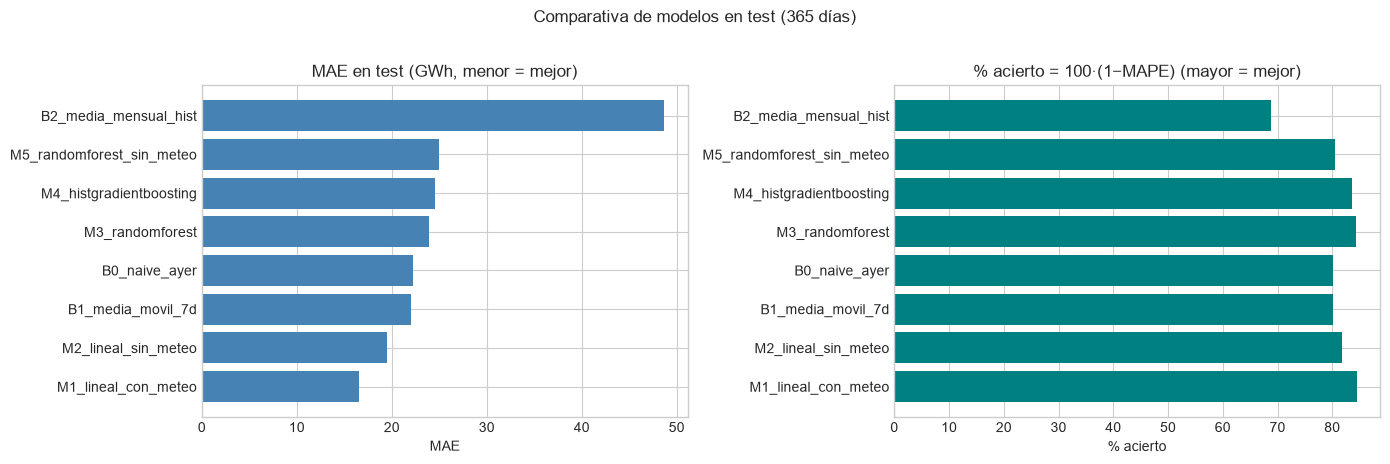

Mejor MAE: M1_lineal_con_meteo | Mejor acierto: M1_lineal_con_meteo


In [18]:
orden = full_df.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(orden, full_df['MAE'].values, color='steelblue')
axes[0].set_title('MAE en test (GWh, menor = mejor)')
axes[0].set_xlabel('MAE')
axes[1].barh(orden, full_df['Acierto'].values, color='teal')
axes[1].set_title('% acierto = 100·(1−MAPE) (mayor = mejor)')
axes[1].set_xlabel('% acierto')
fig.suptitle('Comparativa de modelos en test (365 días)', y=1.02)
fig.tight_layout()
plt.show()
print('Mejor MAE:', full_df.index[0], '| Mejor acierto:', full_df['Acierto'].idxmax())

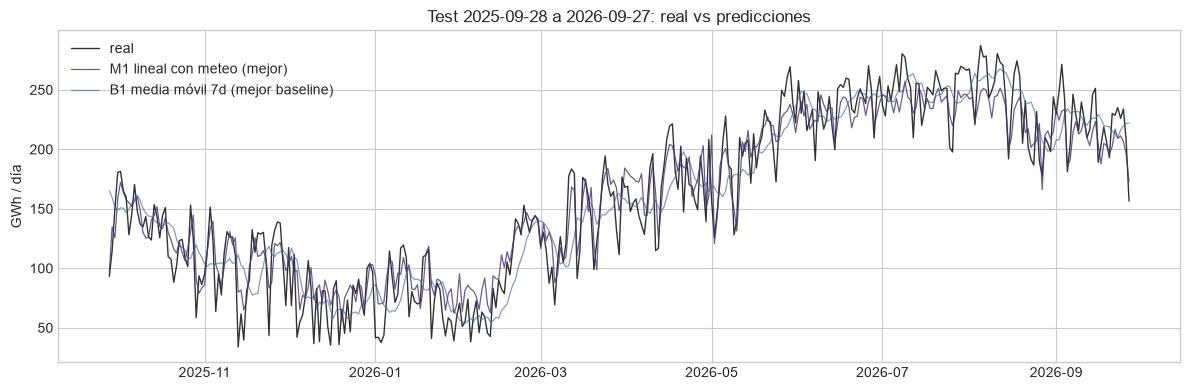

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(test.fecha, yte, lw=1.0, alpha=0.8, label='real', color='black')
ax.plot(test.fecha, preds['M1_lineal_con_meteo'], lw=0.9, alpha=0.8, label='M1 lineal con meteo (mejor)')
ax.plot(test.fecha, test.roll7.values, lw=0.9, alpha=0.6, label='B1 media móvil 7d (mejor baseline)')
ax.set_title('Test 2025-09-28 a 2026-09-27: real vs predicciones')
ax.set_ylabel('GWh / día')
ax.legend()
fig.tight_layout()
plt.show()

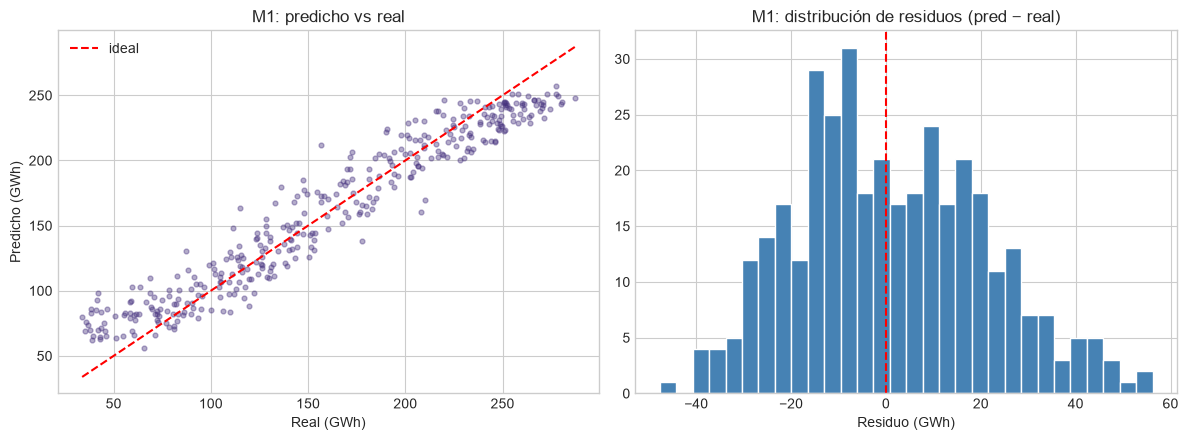

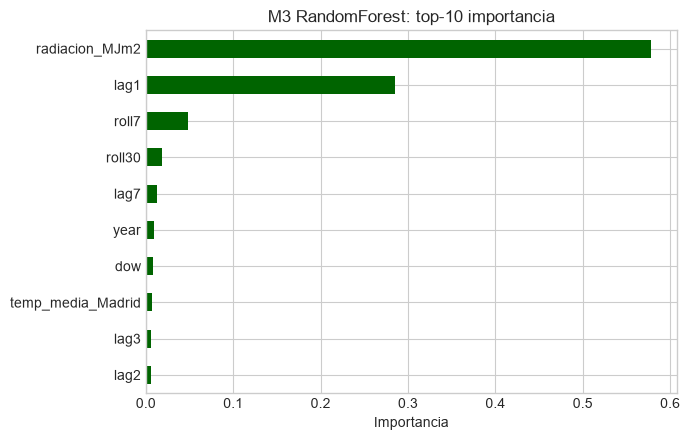

Top-3 RF: roll7, lag1, radiacion_MJm2


In [20]:
p1 = preds['M1_lineal_con_meteo']
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(yte, p1, alpha=0.4, s=12)
axes[0].plot([yte.min(), yte.max()], [yte.min(), yte.max()], 'r--', label='ideal')
axes[0].set_title('M1: predicho vs real')
axes[0].set_xlabel('Real (GWh)')
axes[0].set_ylabel('Predicho (GWh)')
axes[0].legend()
axes[1].hist(p1 - yte, bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', ls='--')
axes[1].set_title('M1: distribución de residuos (pred − real)')
axes[1].set_xlabel('Residuo (GWh)')
fig.tight_layout()
plt.show()
imp = pd.Series(rf_model.feature_importances_, index=rf_feats).sort_values(ascending=True).tail(10)
fig, ax = plt.subplots(figsize=(7, 4.5))
imp.plot(kind='barh', ax=ax, color='darkgreen')
ax.set_title('M3 RandomForest: top-10 importancia')
ax.set_xlabel('Importancia')
fig.tight_layout()
plt.show()
print('Top-3 RF:', ', '.join(imp.tail(3).index.tolist()))

## 6 - Lo que saco en claro

1. El que mejor va es el M1, el lineal con meteo (MAE 16.54, R2 0.919, acierto 84.5%, más de la mitad de días con menos de 10% de error y 82.5% con menos de 20%). Mejora al mejor baseline (B1, 80.2%) en unos 4 puntos.
2. La meteo se nota un montón: el lineal pasa de 81.8% a 84.5% y el RF de 80.5% a 84.3%. Sin meteo ninguno baja de 19.5 de MAE.
3. Los árboles no tiran para arriba con la tendencia: se quedan en MAE ~24, peor que el lineal e incluso que la media móvil, porque 2026 trae más potencia que no vieron. El lineal sí sube con `year` y la recta radiación-solar.
4. Para el día a día: con el M1 (calendario + meteo prevista + últimos 7-30 días) 4 de cada 5 días fallas menos de 20%, que vale para dejar reserva. El resto suelen ser días raros nublados de invierno.
5. Peguitas: uso la meteo real como si fuera la prevista perfecta (en real fallará algo más), Madrid no es toda España y hay que reentrenar cada año porque hay más placas.

**Lo próximo que haría:** reentrenar cada mes con datos nuevos, dar un rango en vez de un número solo y probar con la meteo prevista de verdad.


In [21]:
full_df.to_csv('data/resultados_modelos.csv')
print('Guardado data/resultados_modelos.csv')
print(full_df[['MAE', 'RMSE', 'MAPE', 'R2', 'Acierto', 'p10', 'p20']].to_string())

Guardado data/resultados_modelos.csv
                             MAE   RMSE    MAPE     R2  Acierto   p10   p20
M1_lineal_con_meteo        16.54  20.04  0.1552  0.919     84.5  57.8  82.5
M2_lineal_sin_meteo        19.51  24.24  0.1816  0.882     81.8  46.6  78.1
B1_media_movil_7d          22.03  27.43  0.1978  0.849     80.2  44.7  67.7
B0_naive_ayer              22.20  28.26  0.1985  0.839     80.2  44.9  69.0
M3_randomforest            23.93  30.07  0.1566  0.818     84.3  35.1  67.9
M4_histgradientboosting    24.55  30.99  0.1644  0.807     83.6  34.8  67.1
M5_randomforest_sin_meteo  24.98  30.58  0.1947  0.812     80.5  34.0  68.5
B2_media_mensual_hist      48.70  57.44  0.3110  0.336     68.9   9.9  27.9
